# EV2Gym LLM Curves Generator

Notebook version of `generate_curves.py` 

Agent construction, episode execution (`run_episode`), and plotting all import directly from
`generate_curves.py` / `plot_baseline_comparison.py`


## 1. Setup

In [ ]:
import os
os.environ["LLM_API_KEY"]  = "Your API Key"
os.environ["LLM_BASE_URL"] = "https://api.groq.com/openai/v1"
os.environ["LLM_MODEL"]    = "llama-3.1-8b-instant"
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


def _find_research_root(start: Path) -> Path:
    """Research_Eva/ is the folder with both llm_agents/ and EV2Gym/ as direct
    children. Checked via iterdir() with an exact-case string match, NOT
    Path.exists() -- exists() is case-insensitive on Windows, so a candidate
    of EV2Gym/ itself would falsely satisfy "does a child named EV2Gym exist"
    against its own "ev2gym" package folder (same name, different case).
    Confirmed 2026-07-28: EV2Gym/ also has its own leftover llm_agents/
    folder (stale, from before llm_agents/ was moved to be a sibling of
    EV2Gym/), so with the old exists()-based check EV2Gym/ satisfied BOTH
    conditions and was returned as a false "research root" whenever the
    kernel's cwd started inside EV2Gym/ (e.g. via a workspace/notebook
    default) -- silently misrouting a real 5-seed Groq collection run's
    output CSVs into EV2Gym/llm_agents/curves/ instead of the real
    llm_agents/curves/. iterdir() returns each child's actual on-disk name
    (case preserved), so comparing against the literal "EV2Gym" string is a
    real case-sensitive check even though the filesystem lookup underneath
    it is not.
    """
    candidate = start
    while True:
        if candidate.exists():
            names = {p.name for p in candidate.iterdir()}
            if "llm_agents" in names and "EV2Gym" in names:
                return candidate
        if candidate == candidate.parent:
            break
        candidate = candidate.parent
    raise FileNotFoundError(
        "Could not find Research_Eva root (a folder containing both 'llm_agents/' "
        f"and 'EV2Gym/'), walking up from {start}."
    )


RESEARCH_ROOT = _find_research_root(Path.cwd())
if str(RESEARCH_ROOT) not in sys.path:
    sys.path.insert(0, str(RESEARCH_ROOT))

# Importing these pulls in generate_curves.py's own module-level bootstrap
# (EV2Gym/ added to sys.path, os.chdir to EV2Gym root for its config-relative
# data paths) -- that logic lives there, not duplicated here, so the
# notebook and the CLI script can never drift out of sync.
from llm_agents.tests.generate_curves import (
    build_agent,
    run_episode,
    plot_power_vs_limit,
    plot_price_vs_rate,
    plot_satisfaction,
)

print(f"Research root: {RESEARCH_ROOT}")
print(f"cwd (EV2Gym root, set by generate_curves.py's own bootstrap): {Path.cwd()}")

# Ollama needs no credentials -- these will show "no"/"-- unset --", which is expected now.
print()
print("LLM credentials:")
print(f"  LLM_API_KEY  set: {'yes' if os.getenv('LLM_API_KEY') else 'no'}")
print(f"  LLM_BASE_URL set: {'yes' if os.getenv('LLM_BASE_URL') else 'no'} "
      f"(current: {os.getenv('LLM_BASE_URL', '-- unset, defaults to Ollama local --')})")
print(f"  LLM_MODEL    set: {'yes' if os.getenv('LLM_MODEL') else 'no'}")


Research root: c:\Users\ees25\Downloads\Research_Eva
cwd (EV2Gym root, set by generate_curves.py's own bootstrap): C:\Users\ees25\Downloads\Research_Eva\EV2Gym

LLM credentials:
  LLM_API_KEY  set: yes
  LLM_BASE_URL set: yes (current: https://api.groq.com/openai/v1)
  LLM_MODEL    set: yes


## 2. Config

In [2]:
AGENT = "LLM"  # one of: "LLM", "ChargeAsFastAsPossible", "ChargeAsLateAsPossibleToDesiredCapacity", "DoNothing"
AGENT_MODE = "coordinated"  # "economic" (single-agent) or "coordinated" (multi-agent).
                          # Only used when AGENT == "LLM" -- ignored for baselines.
SEEDS = [0, 1, 2, 3]
MAX_STEPS = 112
OUT_DIR = "llm_agents/curves"

LLM_PROVIDER = "groq"
LLM_MODEL = "llama-3.1-8b-instant"
REPLAN_FREQUENCY = 4

OUT_DIR = RESEARCH_ROOT / OUT_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

# RUN_TAG distinguishes this post-capacity-fix collection from the existing
# LLM_economic_steps.csv (pre-fix data, already has all 5 seeds present).
# Without this, the resumable run cell below would see seeds 0-4 already in
# LLM_economic_steps.csv and skip every single one -- silently doing nothing
# -- since it has no way to know the *adapter* changed underneath it, only
# that the seed number was already logged. Giving the post-fix run its own
# filename stem sidesteps that entirely: it starts from an empty CSV.
RUN_TAG = "postfixnew6"  # set back to "" to target the original (pre-fix) files

# Filename includes AGENT_MODE (and RUN_TAG, when set) whenever AGENT == "LLM":
# without the AGENT_MODE part, switching AGENT_MODE from "economic" to
# "coordinated" and re-running would resolve to the same LLM_steps.csv as
# before, silently mixing single-agent and multi-agent rows in one file (or
# overwriting one with the other, depending on resume state) since nothing
# else in the filename would have changed. Baselines don't depend on
# AGENT_MODE or RUN_TAG at all, so their filenames are left exactly as
# before -- no suffix clutter on those.
if AGENT == "LLM":
    _file_stem = f"{AGENT}_{AGENT_MODE}" + (f"_{RUN_TAG}" if RUN_TAG else "")
else:
    _file_stem = AGENT
STEPS_CSV = OUT_DIR / f"{_file_stem}_steps.csv"
DEPARTURES_CSV = OUT_DIR / f"{_file_stem}_departures.csv"

print(f"Agent          : {AGENT}")
print(f"Agent mode     : {AGENT_MODE if AGENT == 'LLM' else '-- n/a for baselines --'}")
print(f"Run tag        : {RUN_TAG if (AGENT == 'LLM' and RUN_TAG) else '-- none --'}")
print(f"Seeds          : {SEEDS}")
print(f"Max steps      : {MAX_STEPS}")
print(f"Steps CSV      : {STEPS_CSV}")
print(f"Departures CSV : {DEPARTURES_CSV}")


Agent          : LLM
Agent mode     : coordinated
Run tag        : postfixnew6
Seeds          : [0, 1, 2, 3]
Max steps      : 112
Steps CSV      : c:\Users\ees25\Downloads\Research_Eva\llm_agents\curves\LLM_coordinated_postfixnew6_steps.csv
Departures CSV : c:\Users\ees25\Downloads\Research_Eva\llm_agents\curves\LLM_coordinated_postfixnew6_departures.csv


## 3. Agent factory

In [3]:
agent = build_agent(AGENT, llm_provider=LLM_PROVIDER, llm_model=LLM_MODEL, replan_frequency=REPLAN_FREQUENCY, mode=AGENT_MODE)
print(f"Built agent: {AGENT} (mode={AGENT_MODE}) -> {type(agent).__name__}")


Built agent: LLM (mode=coordinated) -> LLMAgent


## 4. Run — incremental save, resumable

Before each seed, checks whether it's already in `{AGENT}_steps.csv` and skips it if so. Appends
each seed's rows to the CSV immediately after it finishes (not batched at the end of the loop), so
an interrupted run loses at most the seed in progress. Per-seed failures are caught and logged; the
loop continues to the next seed rather than aborting the whole run.


In [4]:
def _existing_seeds(csv_path: Path) -> set:
    if not csv_path.exists():
        return set()
    try:
        return set(pd.read_csv(csv_path, usecols=["seed"])["seed"].unique().tolist())
    except Exception:
        return set()


def _append_csv(df: pd.DataFrame, csv_path: Path) -> None:
    df.to_csv(csv_path, mode="a", header=not csv_path.exists(), index=False)


done_seeds = _existing_seeds(STEPS_CSV)
if done_seeds:
    print(f"Resuming: seeds already present in {STEPS_CSV.name}: {sorted(done_seeds)}")

n_complete = len(done_seeds)
for seed in SEEDS:
    if seed in done_seeds:
        print(f"seed={seed} already done, skipping")
        continue
    try:
        steps_df, departures_df = run_episode(agent, seed, MAX_STEPS)
        _append_csv(steps_df, STEPS_CSV)
        _append_csv(departures_df, DEPARTURES_CSV)
        n_complete += 1
        print(f"seed={seed} done ({n_complete}/{len(SEEDS)} complete)")
    except Exception as exc:
        print(f"seed={seed} FAILED: {exc}")
        continue

print(f"\nRun complete for this session: {n_complete}/{len(SEEDS)} seeds done.")


Failed to parse LLM response as JSON: Failed to parse LLM JSON after 3 repair passes: Expecting ',' delimiter: line 18 column 40 (char 830)
Raw response: ```json
{
  "reasoning": "14 EVs connected, 38.7 kW transformer headroom, prioritizing port_3, port_24, port_10, port_11, port_13, port_16, port_21, port_22 for safety/satisfaction due to low SoC and 
Failed to parse coordinator LLM response as JSON: Failed to parse LLM JSON after 3 repair passes: Expecting ',' delimiter: line 1 column 4875 (char 4874)
Raw response: {"reasoning": "Blending both proposals, I chose to prioritize under-charged EVs and those with low departure time, but also ensure safety/satisfaction by charging port_2 and port_24, as per the ENVIRO
Failed to parse coordinator LLM response as JSON: Failed to parse LLM JSON after 3 repair passes: Expecting ',' delimiter: line 1 column 4892 (char 4891)
Raw response: {"reasoning": "Blending both proposals, prioritizing safety and satisfaction by setting power to 11.00 kW fo

seed=0 done (1/4 complete)


llm_action_omission_count=10: active port(s) missing from economic response's actions array, defaulted to 0.0 kW: ['port_0', 'port_1', 'port_14', 'port_16', 'port_2', 'port_20', 'port_21', 'port_24', 'port_5', 'port_6']
llm_action_omission_count=2: active port(s) missing from economic response's actions array, defaulted to 0.0 kW: ['port_0', 'port_7']
llm_action_omission_count=1: active port(s) missing from economic response's actions array, defaulted to 0.0 kW: ['port_2']
llm_action_omission_count=1: active port(s) missing from economic response's actions array, defaulted to 0.0 kW: ['port_2']
No valid actions parsed from LLM response, using fallback (all zeros)
c:\Users\ees25\Downloads\Research_Eva\EV2Gym\.venv\Lib\site-packages\pandas\core\internals\blocks.py:2536: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)


seed=1 done (2/4 complete)


No valid actions parsed from LLM response, using fallback (all zeros)
No valid actions parsed from LLM response, using fallback (all zeros)
No valid actions parsed from LLM response, using fallback (all zeros)
c:\Users\ees25\Downloads\Research_Eva\EV2Gym\.venv\Lib\site-packages\pandas\core\internals\blocks.py:2536: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)


seed=2 done (3/4 complete)


Failed to parse coordinator LLM response as JSON: Failed to parse LLM JSON after 3 repair passes: Expecting ',' delimiter: line 1 column 4886 (char 4885)
Raw response: {"reasoning": "Blending both proposals, I chose to prioritize under-charged EVs and those with low departure time, while also ensuring safety and user satisfaction by allocating 11 kW to port_1 and po
No valid actions parsed from LLM response, using fallback (all zeros)
c:\Users\ees25\Downloads\Research_Eva\EV2Gym\.venv\Lib\site-packages\pandas\core\internals\blocks.py:2536: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)


seed=3 done (4/4 complete)

Run complete for this session: 4/4 seeds done.


## 5. Plots

Each cell re-reads the CSV from disk (so it reflects whatever's actually been run so far, even
across kernel restarts), saves the PNG the same way `generate_curves.py` does, and displays it
inline.

### Power vs. transformer limit

Saved c:\Users\ees25\Downloads\Research_Eva\llm_agents\curves\LLM_power_vs_limit.png


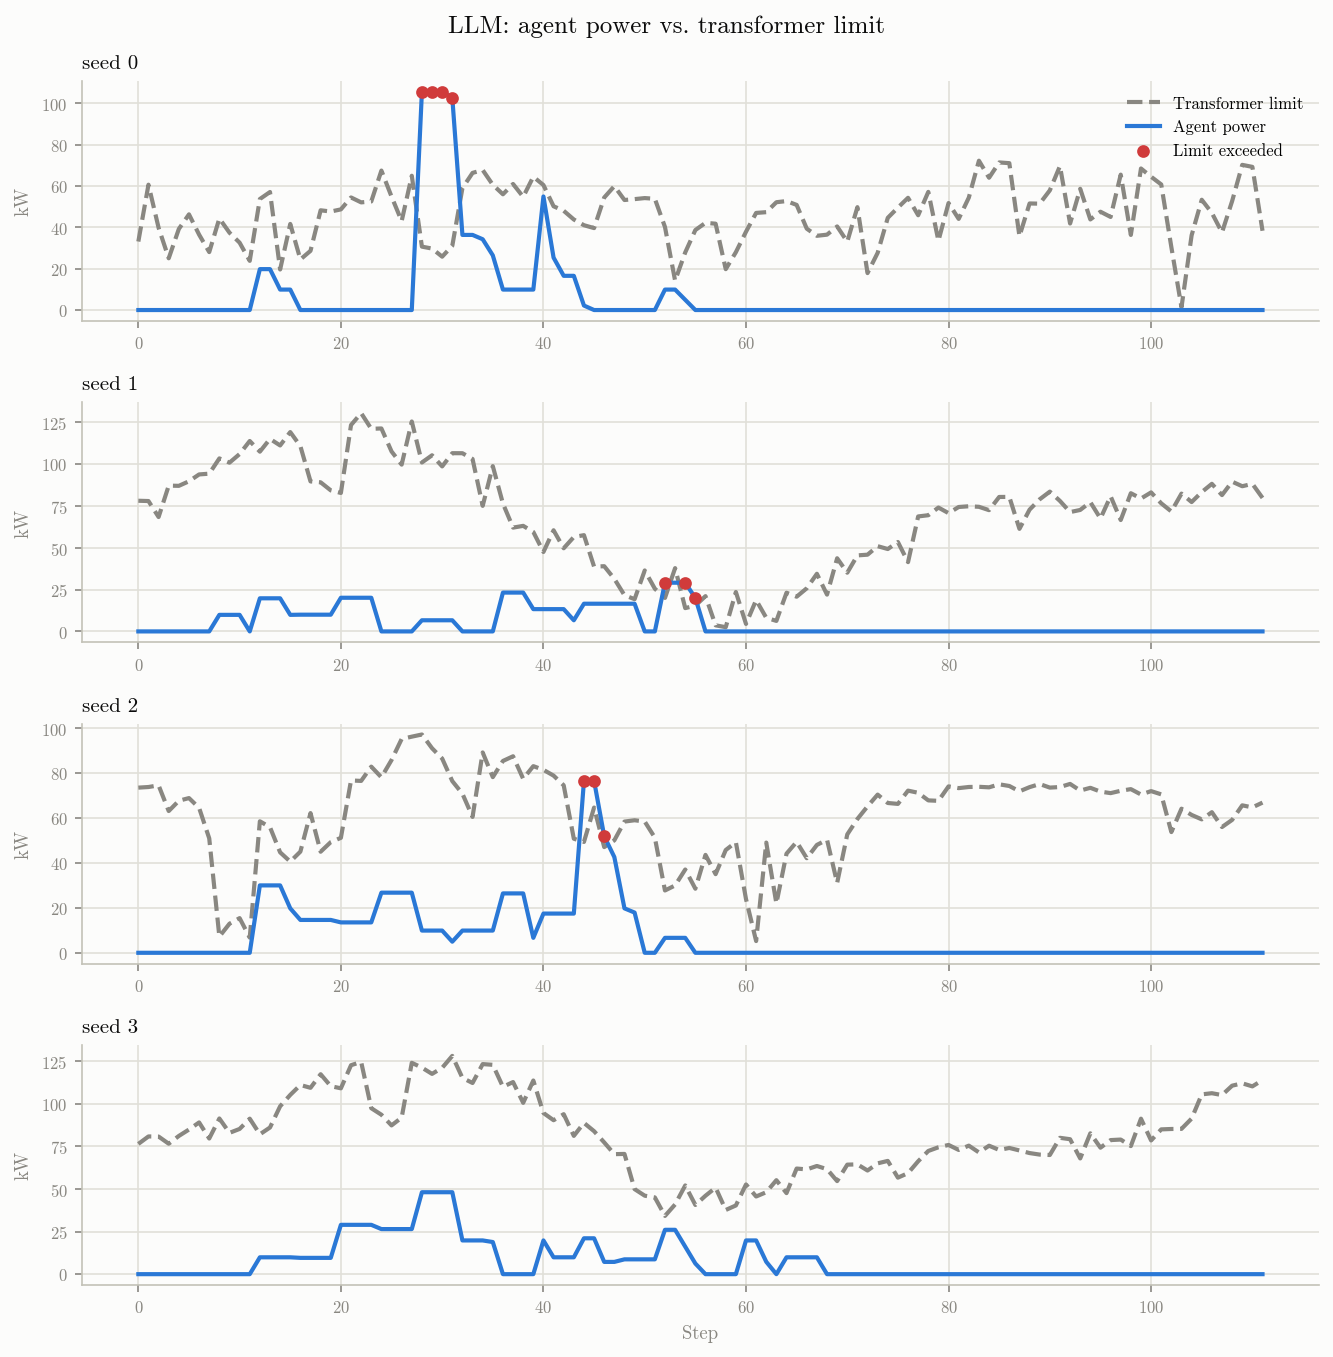

In [5]:
steps_df = pd.read_csv(STEPS_CSV) if STEPS_CSV.exists() else pd.DataFrame()
n_seeds_present = steps_df["seed"].nunique() if len(steps_df) else 0
if n_seeds_present < len(SEEDS):
    print(f"Note: only {n_seeds_present}/{len(SEEDS)} seeds available -- plotting what exists.")

if len(steps_df):
    out_path = OUT_DIR / f"{AGENT}_power_vs_limit.png"
    plot_power_vs_limit(steps_df, AGENT, out_path)
    display(Image(filename=str(out_path)))
else:
    print("No step data yet -- run the previous cell first.")


### Price vs. charging rate

c:\Users\ees25\Downloads\Research_Eva\llm_agents\tests\generate_curves.py:365: UserWarning: Glyph 8364 (\N{EURO SIGN}) missing from font(s) cmr10.
  fig.tight_layout()
c:\Users\ees25\Downloads\Research_Eva\llm_agents\tests\generate_curves.py:366: UserWarning: Glyph 8364 (\N{EURO SIGN}) missing from font(s) cmr10.
  fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=COLOR_SURFACE)


Saved c:\Users\ees25\Downloads\Research_Eva\llm_agents\curves\LLM_price_vs_rate.png


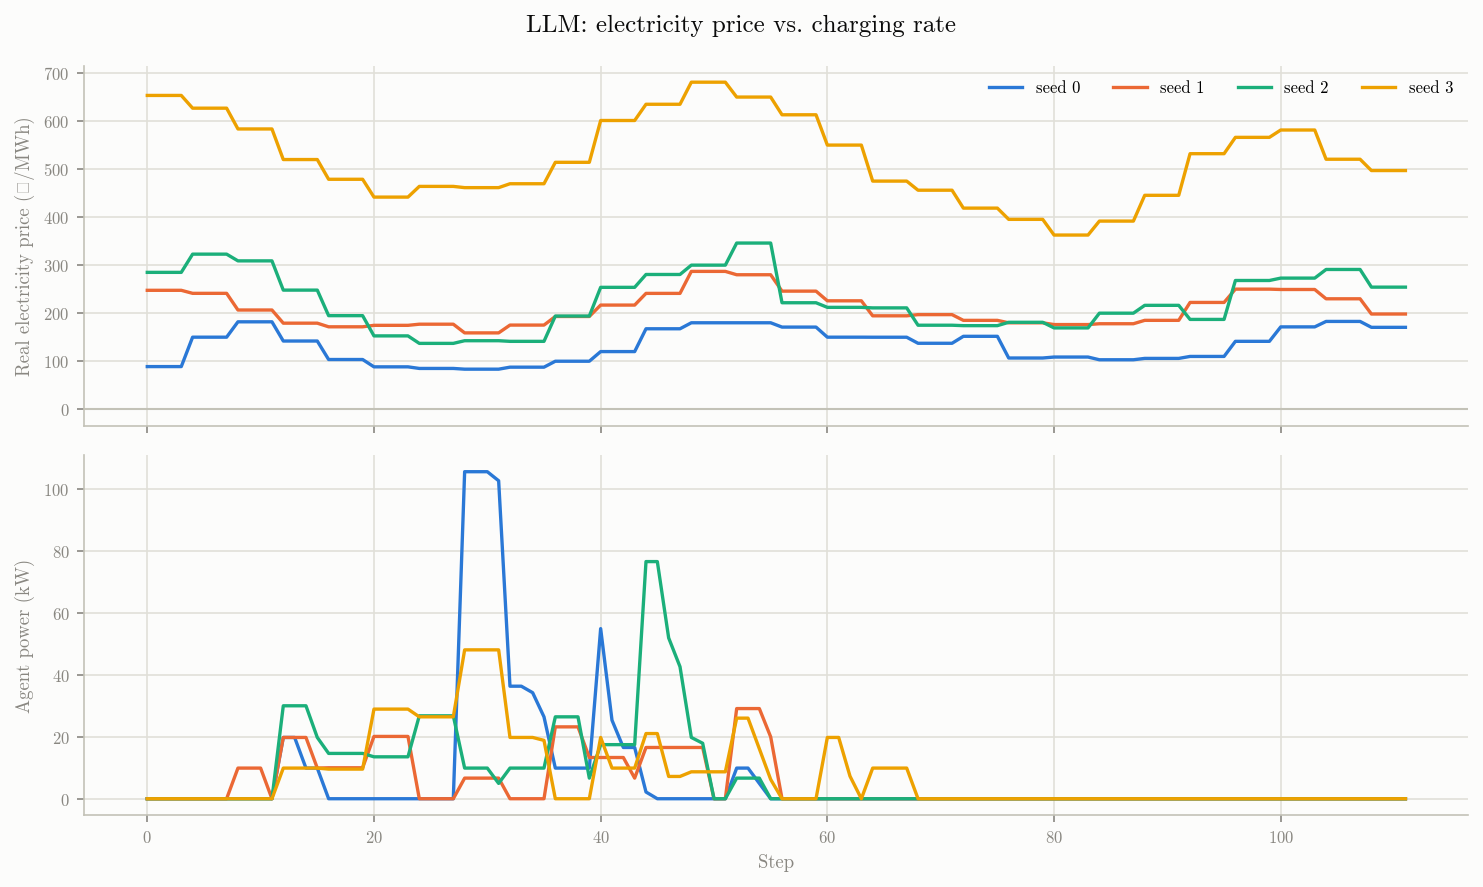

In [6]:
steps_df = pd.read_csv(STEPS_CSV) if STEPS_CSV.exists() else pd.DataFrame()
n_seeds_present = steps_df["seed"].nunique() if len(steps_df) else 0
if n_seeds_present < len(SEEDS):
    print(f"Note: only {n_seeds_present}/{len(SEEDS)} seeds available -- plotting what exists.")

if len(steps_df):
    out_path = OUT_DIR / f"{AGENT}_price_vs_rate.png"
    plot_price_vs_rate(steps_df, AGENT, out_path)
    display(Image(filename=str(out_path)))
else:
    print("No step data yet -- run the previous cell first.")


### Satisfaction at departure

Saved c:\Users\ees25\Downloads\Research_Eva\llm_agents\curves\LLM_satisfaction.png


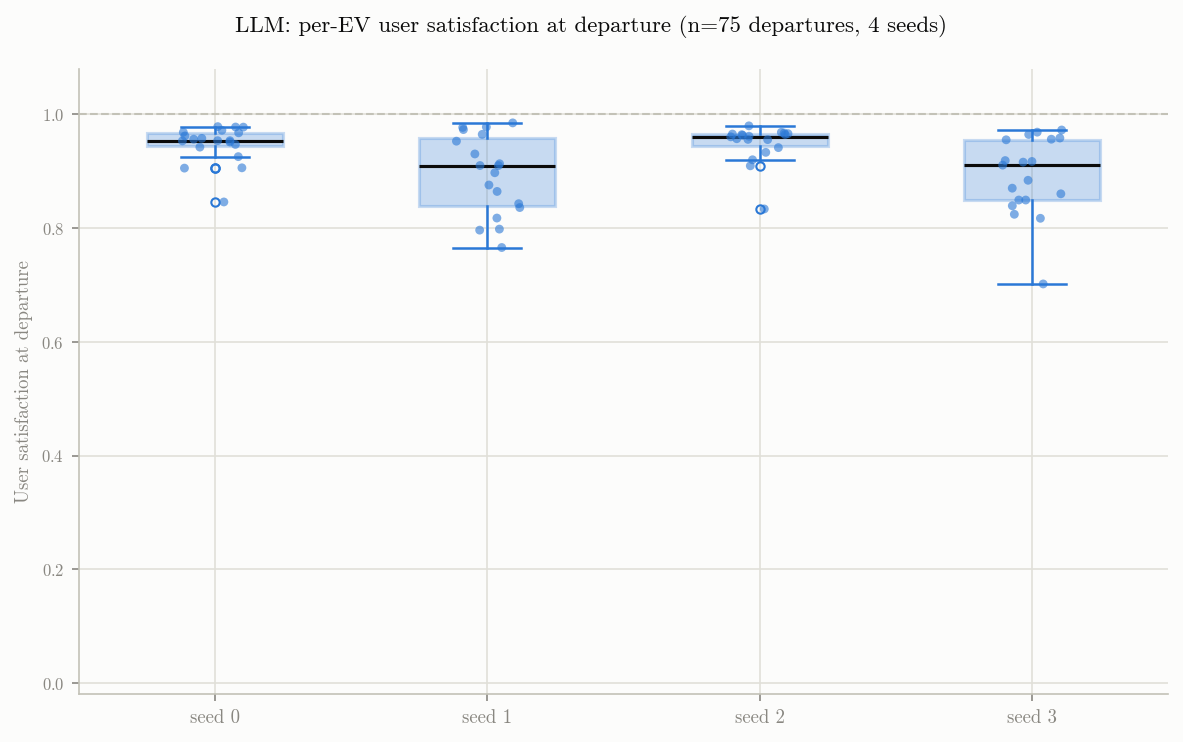

In [7]:
departures_df = pd.read_csv(DEPARTURES_CSV) if DEPARTURES_CSV.exists() else pd.DataFrame()
n_seeds_present = departures_df["seed"].nunique() if len(departures_df) else 0
if n_seeds_present < len(SEEDS):
    print(f"Note: only {n_seeds_present}/{len(SEEDS)} seeds available -- plotting what exists.")

if len(departures_df):
    out_path = OUT_DIR / f"{AGENT}_satisfaction.png"
    plot_satisfaction(departures_df, AGENT, out_path)
    display(Image(filename=str(out_path)))
else:
    print("No departures yet -- either the run hasn't happened, or no EV had departed within MAX_STEPS.")


## 6. Combined comparison — all agents

Loads whichever of `{DoNothing, ChargeAsFastAsPossible, ChargeAsLateAsPossibleToDesiredCapacity,
LLM}_steps.csv` currently exist in `OUT_DIR` and builds the same 3-panel `full_comparison.png` /
`baseline_comparison.png` that `plot_baseline_comparison.py` produces from the command line.
Prints which agents are still missing rather than erroring if fewer than 4 are present.

c:\Users\ees25\Downloads\Research_Eva\EV2Gym\.venv\Lib\site-packages\pandas\core\internals\blocks.py:2536: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)


Saved C:\Users\ees25\Downloads\Research_Eva\llm_agents\curves\baseline_summary_coordinated.csv
                                  agent  mean_power_kw  transformer_violations  price_action_correlation  mean_satisfaction  parse_failure_rate  satisfaction_above_donothing  price_correlation_vs_llm
                              DoNothing          0.000                       0                       NaN             0.7368              0.0000                        0.0000                       NaN
                                    LLM          6.948                      10                   -0.0035             0.9198              3.5714                        0.1830                    0.0000
                 ChargeAsFastAsPossible         10.262                      19                   -0.0358             1.0000              0.0000                        0.2632                    0.0323
ChargeAsLateAsPossibleToDesiredCapacity         10.012                      46                    0.1609 

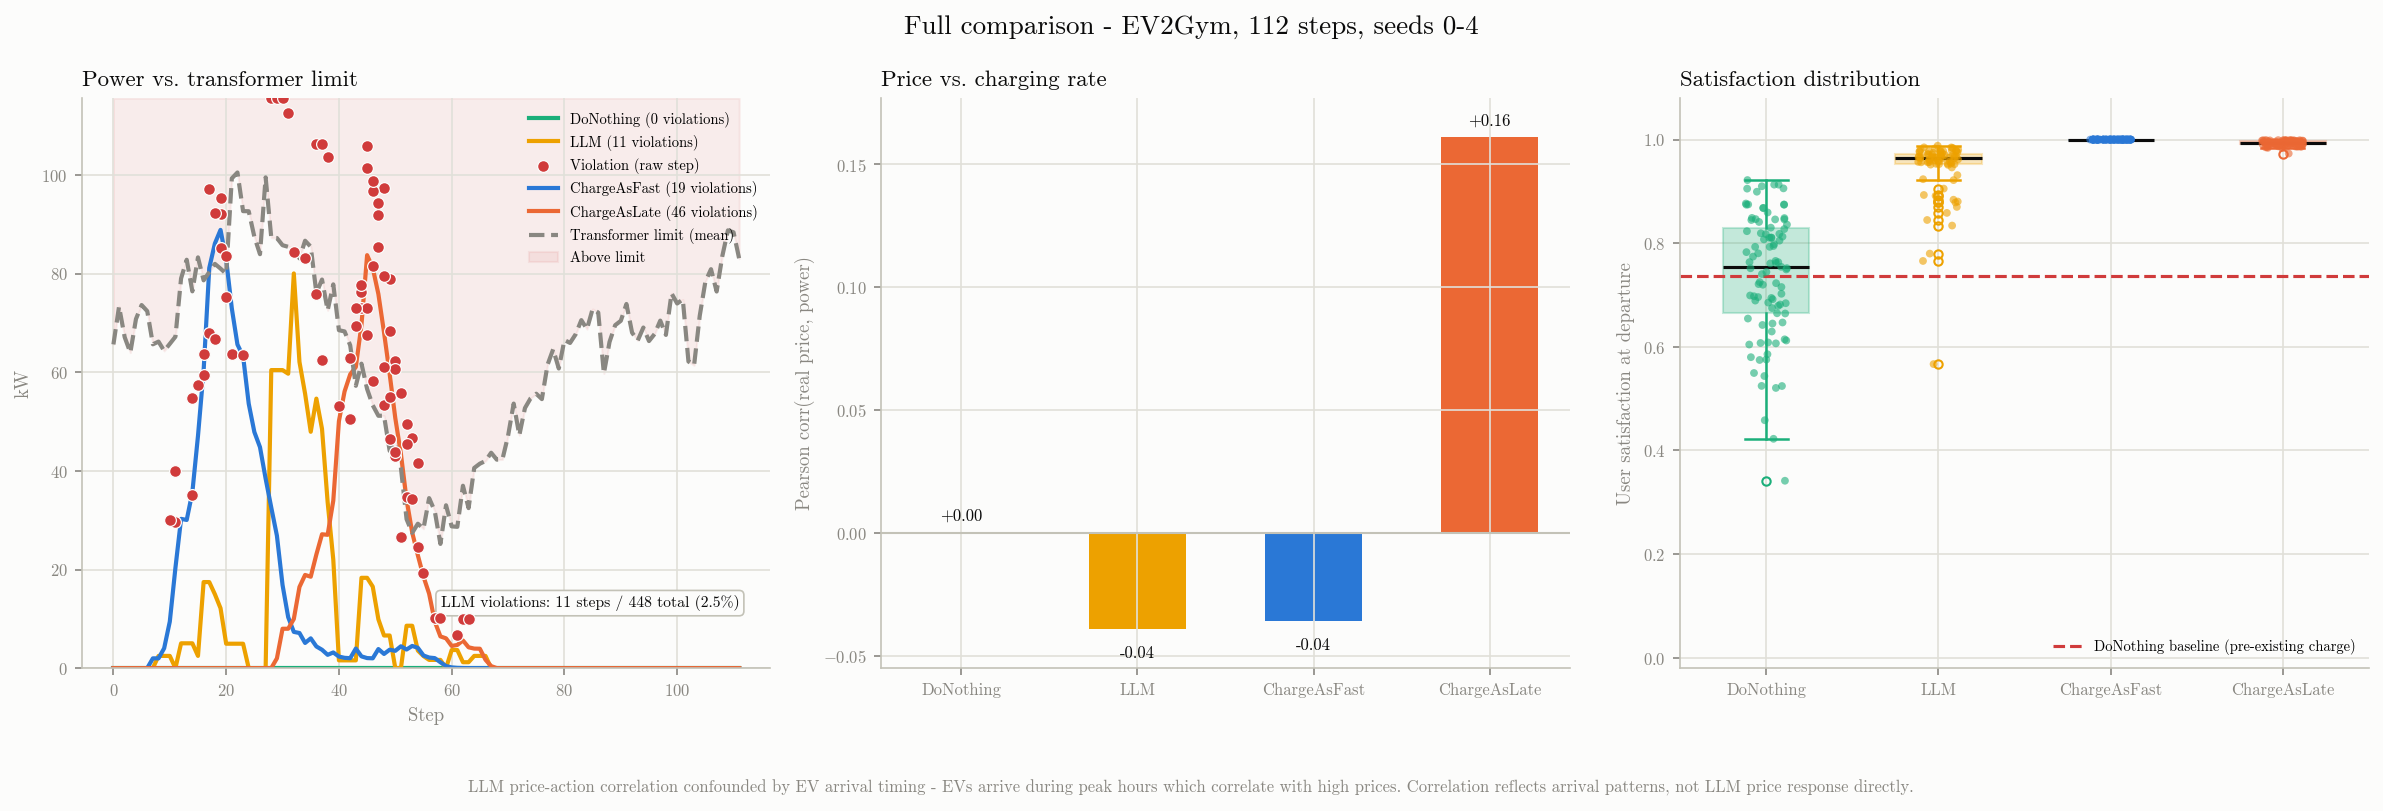

In [8]:
from llm_agents.tests import plot_baseline_comparison as pbc

# This notebook names its LLM output by AGENT_MODE + RUN_TAG (see Section 2's
# _file_stem logic), so the combined comparison must look for that same full
# stem -- not the CLI script's fixed "LLM_steps.csv", and not just
# "LLM_{AGENT_MODE}" without RUN_TAG (which would silently read a stale/
# untagged LLM CSV instead of whatever this session's Run cell in Section 4
# actually just collected). Built explicitly here rather than reusing Section
# 2's _file_stem, since _file_stem tracks whatever AGENT is currently set to
# (which may be a baseline, not "LLM") -- this cell always needs the LLM-
# specific stem regardless of AGENT.
llm_steps_stem = f"LLM_{AGENT_MODE}" + (f"_{RUN_TAG}" if RUN_TAG else "")

try:
    pbc.main(llm_steps_stem=llm_steps_stem)
    combined_png = pbc.CURVES_DIR / (
        "full_comparison.png" if (pbc.CURVES_DIR / f"{llm_steps_stem}_steps.csv").exists() else "baseline_comparison.png"
    )
    if combined_png.exists():
        display(Image(filename=str(combined_png)))
except FileNotFoundError as exc:
    print(f"Cannot build combined comparison yet: {exc}")
